In [1]:
# CELL 1 — Install packages
!pip install tensorflow scikit-learn seaborn -q
print('✅ All packages installed')

✅ All packages installed


In [2]:
# CELL 2 — Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')
import os
print('✅ Drive mounted')
print('\nFiles in Drive:')
for f in os.listdir('/content/drive/MyDrive/'):
    print(f'  {f}')

Mounted at /content/drive
✅ Drive mounted

Files in Drive:
  25MCA1074.docx
  Colab Notebooks
  Resume(25MCA1074).pdf
  genai_models
  models
  muskan_resume_.pdf
  muskan_newnewresume.pdf
  qlora_medical_adapter
  archive.zip
  breeddataset_reduce.zip
  BCS_DATASET_N.zip


In [3]:
# CELL 3 — Extract ALL 3 datasets
import zipfile, os

# Breed dataset
print('Extracting breed dataset...')
os.makedirs('/content/datasets/breed', exist_ok=True)
with zipfile.ZipFile('/content/drive/MyDrive/breeddataset_reduce.zip', 'r') as z:
    z.extractall('/content/datasets/breed')
print('✅ Breed extracted!')

# Health dataset
print('Extracting health dataset...')
os.makedirs('/content/datasets/health_raw', exist_ok=True)
with zipfile.ZipFile('/content/drive/MyDrive/archive.zip', 'r') as z:
    z.extractall('/content/datasets/health_raw')
print('✅ Health extracted!')

# BCS dataset
print('Extracting BCS dataset...')
os.makedirs('/content/datasets/bcs_raw', exist_ok=True)
with zipfile.ZipFile('/content/drive/MyDrive/BCS_DATASET_N.zip', 'r') as z:
    z.extractall('/content/datasets/bcs_raw')
print('✅ BCS extracted!')

Extracting breed dataset...
✅ Breed extracted!
Extracting health dataset...
✅ Health extracted!
Extracting BCS dataset...
✅ BCS extracted!


In [4]:
# CELL 4 — Organize BREED dataset
import os, shutil, glob
from sklearn.model_selection import train_test_split

BREED_RAW   = '/content/datasets/breed'
BREED_SPLIT = '/content/data/breed'

EXCLUDE = {'healthy','unhealthy','diseased','lumpy','foot-and-mouth',
           'fmd','sick','normal','cows datasets','total_sorted_dge_images'}

class_dirs = []
for root, dirs, files in os.walk(BREED_RAW):
    folder = os.path.basename(root)
    if folder.lower() in EXCLUDE:
        continue
    imgs = [f for f in files if f.lower().endswith(('.jpg','.jpeg','.png','.bmp'))]
    if len(imgs) >= 5:
        class_dirs.append((folder, root, imgs))

print(f'✅ Found {len(class_dirs)} breed classes:')
for name, _, imgs in class_dirs:
    print(f'  {name}: {len(imgs)} images')

for cls_name, cls_path, img_files in class_dirs:
    full = [os.path.join(cls_path, f) for f in img_files]
    train_imgs, temp = train_test_split(full, test_size=0.3, random_state=42)
    val_imgs, test_imgs = train_test_split(temp, test_size=0.33, random_state=42)
    for split, imgs in [('train',train_imgs),('val',val_imgs),('test',test_imgs)]:
        dest = os.path.join(BREED_SPLIT, split, cls_name)
        os.makedirs(dest, exist_ok=True)
        for img in imgs:
            try: shutil.copy(img, dest)
            except: pass

for split in ['train','val','test']:
    total = len(glob.glob(os.path.join(BREED_SPLIT, split, '*', '*.*')))
    n_cls = len(os.listdir(os.path.join(BREED_SPLIT, split)))
    print(f'{split}: {total} images, {n_cls} classes')
print('✅ Breed organized!')

✅ Found 18 breed classes:
  Ayrshire: 35 images
  Guernesy: 10 images
  Red_Sindhi: 26 images
  Alambadi: 30 images
  Kangayam: 6 images
  Amritmahal: 35 images
  Nagpuri: 15 images
  Bargur: 20 images
  Banni: 24 images
  Vechur: 16 images
  Gir: 25 images
  Rathi: 11 images
  Dangi: 12 images
  Surti: 9 images
  Sahiwal: 18 images
  Jersey: 35 images
  Khillari: 11 images
  Bhadwari: 22 images
train: 245 images, 18 classes
val: 71 images, 18 classes
test: 44 images, 18 classes
✅ Breed organized!


In [5]:
# CELL 5 — Organize HEALTH dataset
import os, shutil, glob
from sklearn.model_selection import train_test_split

HEALTH_RAW   = None
HEALTH_SPLIT = '/content/data/health'

for path in ['/content/datasets/health_raw/Cows datasets',
             '/content/datasets/health_raw']:
    if os.path.exists(path):
        classes = [d for d in os.listdir(path)
                   if os.path.isdir(os.path.join(path, d))]
        if len(classes) >= 2:
            HEALTH_RAW = path
            print(f'✅ Health found: {path}')
            print(f'   Classes: {classes}')
            break

if HEALTH_RAW is None:
    print('❌ Health data not found!')
else:
    for cls in [d for d in os.listdir(HEALTH_RAW)
                if os.path.isdir(os.path.join(HEALTH_RAW, d))]:
        cls_path = os.path.join(HEALTH_RAW, cls)
        images = (glob.glob(os.path.join(cls_path,'*.jpg')) +
                  glob.glob(os.path.join(cls_path,'*.jpeg')) +
                  glob.glob(os.path.join(cls_path,'*.png')))
        if len(images) < 5: continue
        train_imgs, temp = train_test_split(images, test_size=0.3, random_state=42)
        val_imgs, test_imgs = train_test_split(temp, test_size=0.5, random_state=42)
        for split, imgs in [('train',train_imgs),('val',val_imgs),('test',test_imgs)]:
            dest = os.path.join(HEALTH_SPLIT, split, cls)
            os.makedirs(dest, exist_ok=True)
            for img in imgs:
                try: shutil.copy(img, dest)
                except: pass
    for split in ['train','val','test']:
        total = len(glob.glob(os.path.join(HEALTH_SPLIT, split, '*', '*.*')))
        classes = os.listdir(os.path.join(HEALTH_SPLIT, split))
        print(f'{split}: {total} images | {classes}')
    print('✅ Health organized!')

✅ Health found: /content/datasets/health_raw/Cows datasets
   Classes: ['foot-and-mouth', 'healthy', 'lumpy']
train: 2267 images | ['foot-and-mouth', 'healthy', 'lumpy']
val: 486 images | ['foot-and-mouth', 'healthy', 'lumpy']
test: 488 images | ['foot-and-mouth', 'healthy', 'lumpy']
✅ Health organized!


In [6]:
# CELL 6 — Organize BCS dataset
import os, shutil, glob
from sklearn.model_selection import train_test_split

BCS_RAW   = '/content/datasets/bcs_raw/BCS_DATASET_N'
BCS_SPLIT = '/content/data/bcs'

if not os.path.exists(BCS_RAW):
    BCS_RAW = '/content/datasets/bcs_raw'

classes = sorted([d for d in os.listdir(BCS_RAW)
                  if os.path.isdir(os.path.join(BCS_RAW,d))
                  and d.strip().isdigit()])
print(f'✅ BCS classes: {classes}')

for cls in classes:
    cls_path = os.path.join(BCS_RAW, cls)
    images = [i for i in
              glob.glob(os.path.join(cls_path,'**','*.*'), recursive=True)
              if i.lower().endswith(('.jpg','.jpeg','.png','.tif','.tiff'))]
    print(f'  BCS {cls}: {len(images)} images')
    if len(images) < 5: continue
    train_imgs, temp = train_test_split(images, test_size=0.3, random_state=42)
    val_imgs, test_imgs = train_test_split(temp, test_size=0.33, random_state=42)
    for split, imgs in [('train',train_imgs),('val',val_imgs),('test',test_imgs)]:
        dest = os.path.join(BCS_SPLIT, split, f'BCS_{cls}')
        os.makedirs(dest, exist_ok=True)
        for img in imgs:
            try: shutil.copy(img, dest)
            except: pass

for split in ['train','val','test']:
    total = len(glob.glob(os.path.join(BCS_SPLIT, split, '*', '*.*')))
    print(f'{split}: {total} images')
print('✅ BCS organized!')

✅ BCS classes: ['2', '3', '4', '5']
  BCS 2: 546 images
  BCS 3: 536 images
  BCS 4: 2212 images
  BCS 5: 1962 images
train: 1398 images
val: 660 images
test: 416 images
✅ BCS organized!


In [7]:
# CELL 7 — Train BREED Model (epochs=5)
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt, json, os, shutil

IMG_SIZE   = 224
BATCH_SIZE = 32
BREED_DIR  = '/content/data/breed'

train_gen = ImageDataGenerator(
    rescale=1./255, rotation_range=20,
    width_shift_range=0.2, height_shift_range=0.2,
    horizontal_flip=True, zoom_range=0.2,
    brightness_range=[0.8, 1.2]
)
val_gen = ImageDataGenerator(rescale=1./255)

train_data = train_gen.flow_from_directory(
    f'{BREED_DIR}/train', target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical'
)
val_data = val_gen.flow_from_directory(
    f'{BREED_DIR}/val', target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical'
)

NUM_CLASSES = len(train_data.class_indices)
print(f'Breeds: {NUM_CLASSES} — {list(train_data.class_indices.keys())}')

with open('/content/breed_classes.json','w') as f:
    json.dump(train_data.class_indices, f)
print('✅ breed_classes.json saved')

base = MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3),
                   include_top=False, weights='imagenet')
base.trainable = False

inputs  = tf.keras.Input(shape=(IMG_SIZE,IMG_SIZE,3))
x       = base(inputs, training=False)
x       = layers.GlobalAveragePooling2D()(x)
x       = layers.Dense(256, activation='relu')(x)
x       = layers.Dropout(0.4)(x)
x       = layers.Dense(128, activation='relu')(x)
x       = layers.Dropout(0.3)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

breed_model = Model(inputs, outputs)
breed_model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy', metrics=['accuracy']
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3, factor=0.5)
]

print('Phase 1: Training...')
history1 = breed_model.fit(train_data, validation_data=val_data,
                            epochs=5, callbacks=callbacks)

print('Phase 2: Fine-tuning...')
base.trainable = True
for layer in base.layers[:-30]:
    layer.trainable = False
breed_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                    loss='categorical_crossentropy', metrics=['accuracy'])
history2 = breed_model.fit(train_data, validation_data=val_data,
                            epochs=5, callbacks=callbacks)

# Save model in KERAS format (no compatibility issues)
breed_model.save('/content/breed_model.keras')
print('✅ breed_model.keras saved!')

# Also save to Drive immediately
os.makedirs('/content/drive/MyDrive/cattleai_models', exist_ok=True)
shutil.copy('/content/breed_model.keras',
            '/content/drive/MyDrive/cattleai_models/breed_model.keras')
shutil.copy('/content/breed_classes.json',
            '/content/drive/MyDrive/cattleai_models/breed_classes.json')
print('✅ Saved to Drive!')

Found 245 images belonging to 18 classes.
Found 71 images belonging to 18 classes.
Breeds: 18 — ['Alambadi', 'Amritmahal', 'Ayrshire', 'Banni', 'Bargur', 'Bhadwari', 'Dangi', 'Gir', 'Guernesy', 'Jersey', 'Kangayam', 'Khillari', 'Nagpuri', 'Rathi', 'Red_Sindhi', 'Sahiwal', 'Surti', 'Vechur']
✅ breed_classes.json saved
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Phase 1: Training...
Epoch 1/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 62s 6s/step - accuracy: 0.0816 - loss: 3.2532 - val_accuracy: 0.2254 - val_loss: 2.6917 - learning_rate: 0.0010
Epoch 2/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 8s 1s/step - accuracy: 0.1143 - loss: 2.8377 - val_accuracy: 0.3239 - val_loss: 2.5779 - learning_rate: 0.0010
Epoch 3/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.1796 - loss: 2.6480 - val_accuracy: 0.3380 - val_loss: 2.5024 - learning_rate: 0.0010
Epoch 4/5
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 929ms/step - accuracy: 0.2531 - loss: 2.4871 - val_accuracy: 0.3662 - val_loss: 2.3701 - learning_rate: 0.0010
Epoch 5/5
8/8 ━━━━━━━━━

In [8]:
# CELL 8 — Train HEALTH Model (epochs=5)
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import json, os, shutil

IMG_SIZE   = 224
BATCH_SIZE = 32
HEALTH_DIR = '/content/data/health'

classes = os.listdir(f'{HEALTH_DIR}/train')
print(f'Health classes: {classes}')
num_health   = len(classes)
class_mode   = 'categorical'
loss_fn      = 'categorical_crossentropy'
final_units  = num_health
final_act    = 'softmax'

train_gen = ImageDataGenerator(rescale=1./255, rotation_range=15,
                                horizontal_flip=True, zoom_range=0.15)
val_gen   = ImageDataGenerator(rescale=1./255)

train_h = train_gen.flow_from_directory(
    f'{HEALTH_DIR}/train', target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode=class_mode
)
val_h = val_gen.flow_from_directory(
    f'{HEALTH_DIR}/val', target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode=class_mode
)

print(f'Health indices: {train_h.class_indices}')
with open('/content/health_classes.json','w') as f:
    json.dump(train_h.class_indices, f)
print('✅ health_classes.json saved')

base_h = MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3),
                     include_top=False, weights='imagenet')
base_h.trainable = False

inp = tf.keras.Input(shape=(IMG_SIZE,IMG_SIZE,3))
x   = base_h(inp, training=False)
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(128, activation='relu')(x)
x   = layers.Dropout(0.4)(x)
out = layers.Dense(final_units, activation=final_act)(x)

health_model = Model(inp, out)
health_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                     loss=loss_fn, metrics=['accuracy'])

callbacks_h = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3)
]

print('Phase 1: Training...')
health_model.fit(train_h, validation_data=val_h,
                 epochs=5, callbacks=callbacks_h)

print('Phase 2: Fine-tuning...')
base_h.trainable = True
for layer in base_h.layers[:-20]:
    layer.trainable = False
health_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                     loss=loss_fn, metrics=['accuracy'])
health_model.fit(train_h, validation_data=val_h,
                 epochs=5, callbacks=callbacks_h)

health_model.save('/content/health_model.keras')
print('✅ health_model.keras saved!')

shutil.copy('/content/health_model.keras',
            '/content/drive/MyDrive/cattleai_models/health_model.keras')
shutil.copy('/content/health_classes.json',
            '/content/drive/MyDrive/cattleai_models/health_classes.json')
print('✅ Saved to Drive!')

Health classes: ['foot-and-mouth', 'healthy', 'lumpy']
Found 2267 images belonging to 3 classes.
Found 486 images belonging to 3 classes.
Health indices: {'foot-and-mouth': 0, 'healthy': 1, 'lumpy': 2}
✅ health_classes.json saved
Phase 1: Training...
Epoch 1/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 72s 902ms/step - accuracy: 0.7569 - loss: 0.5923 - val_accuracy: 0.8539 - val_loss: 0.3387 - learning_rate: 0.0010
Epoch 2/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 34s 484ms/step - accuracy: 0.8699 - loss: 0.3450 - val_accuracy: 0.8745 - val_loss: 0.2927 - learning_rate: 0.0010
Epoch 3/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 36s 504ms/step - accuracy: 0.8924 - loss: 0.3010 - val_accuracy: 0.8663 - val_loss: 0.3005 - learning_rate: 0.0010
Epoch 4/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 35s 491ms/step - accuracy: 0.9038 - loss: 0.2478 - val_accuracy: 0.9012 - val_loss: 0.2486 - learning_rate: 0.0010
Epoch 5/5
71/71 ━━━━━━━━━━━━━━━━━━━━ 39s 546ms/step - accuracy: 0.9065 - loss: 0.2363 - val_accuracy: 0.8992 - val_loss: 0.2453 - learning_ra

In [9]:
# CELL 9 — Train BCS Model (epochs=5)
import tensorflow as tf
from tensorflow.keras import layers, Model
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import json, os, shutil

IMG_SIZE   = 224
BATCH_SIZE = 32
BCS_DIR    = '/content/data/bcs'

train_classes = sorted(os.listdir(f'{BCS_DIR}/train'))
print(f'BCS classes: {train_classes}')

train_gen = ImageDataGenerator(rescale=1./255, rotation_range=20,
                                horizontal_flip=True, zoom_range=0.2,
                                brightness_range=[0.8,1.2])
val_gen   = ImageDataGenerator(rescale=1./255)

train_bcs = train_gen.flow_from_directory(
    f'{BCS_DIR}/train', target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical'
)
val_bcs = val_gen.flow_from_directory(
    f'{BCS_DIR}/val', target_size=(IMG_SIZE,IMG_SIZE),
    batch_size=BATCH_SIZE, class_mode='categorical'
)

NUM_BCS = len(train_bcs.class_indices)
print(f'BCS indices: {train_bcs.class_indices}')
with open('/content/bcs_classes.json','w') as f:
    json.dump(train_bcs.class_indices, f)
print('✅ bcs_classes.json saved')

base_bcs = MobileNetV2(input_shape=(IMG_SIZE,IMG_SIZE,3),
                       include_top=False, weights='imagenet')
base_bcs.trainable = False

inp = tf.keras.Input(shape=(IMG_SIZE,IMG_SIZE,3))
x   = base_bcs(inp, training=False)
x   = layers.GlobalAveragePooling2D()(x)
x   = layers.Dense(256, activation='relu')(x)
x   = layers.Dropout(0.4)(x)
x   = layers.Dense(128, activation='relu')(x)
x   = layers.Dropout(0.3)(x)
out = layers.Dense(NUM_BCS, activation='softmax')(x)

bcs_model = Model(inp, out)
bcs_model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                  loss='categorical_crossentropy', metrics=['accuracy'])

callbacks_bcs = [
    tf.keras.callbacks.EarlyStopping(patience=5, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(patience=3)
]

print('Phase 1: Training...')
bcs_model.fit(train_bcs, validation_data=val_bcs,
              epochs=5, callbacks=callbacks_bcs)

print('Phase 2: Fine-tuning...')
base_bcs.trainable = True
for layer in base_bcs.layers[:-30]:
    layer.trainable = False
bcs_model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                  loss='categorical_crossentropy', metrics=['accuracy'])
bcs_model.fit(train_bcs, validation_data=val_bcs,
              epochs=5, callbacks=callbacks_bcs)

bcs_model.save('/content/bcs_model.keras')
print('✅ bcs_model.keras saved!')

shutil.copy('/content/bcs_model.keras',
            '/content/drive/MyDrive/cattleai_models/bcs_model.keras')
shutil.copy('/content/bcs_classes.json',
            '/content/drive/MyDrive/cattleai_models/bcs_classes.json')
print('✅ Saved to Drive!')

BCS classes: ['BCS_2', 'BCS_3', 'BCS_4', 'BCS_5']
Found 1398 images belonging to 4 classes.
Found 660 images belonging to 4 classes.
BCS indices: {'BCS_2': 0, 'BCS_3': 1, 'BCS_4': 2, 'BCS_5': 3}
✅ bcs_classes.json saved
Phase 1: Training...
Epoch 1/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 60s 1s/step - accuracy: 0.5401 - loss: 1.1356 - val_accuracy: 0.6348 - val_loss: 0.8558 - learning_rate: 0.0010
Epoch 2/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 442ms/step - accuracy: 0.6588 - loss: 0.8162 - val_accuracy: 0.7045 - val_loss: 0.7633 - learning_rate: 0.0010
Epoch 3/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 468ms/step - accuracy: 0.6996 - loss: 0.7061 - val_accuracy: 0.6803 - val_loss: 0.7410 - learning_rate: 0.0010
Epoch 4/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 19s 441ms/step - accuracy: 0.7368 - loss: 0.6166 - val_accuracy: 0.7515 - val_loss: 0.6043 - learning_rate: 0.0010
Epoch 5/5
44/44 ━━━━━━━━━━━━━━━━━━━━ 21s 485ms/step - accuracy: 0.7625 - loss: 0.5721 - val_accuracy: 0.7364 - val_loss: 0.6391 - learning_rate: 0.0010
Ph

Breed: Ayrshire (57.28%)


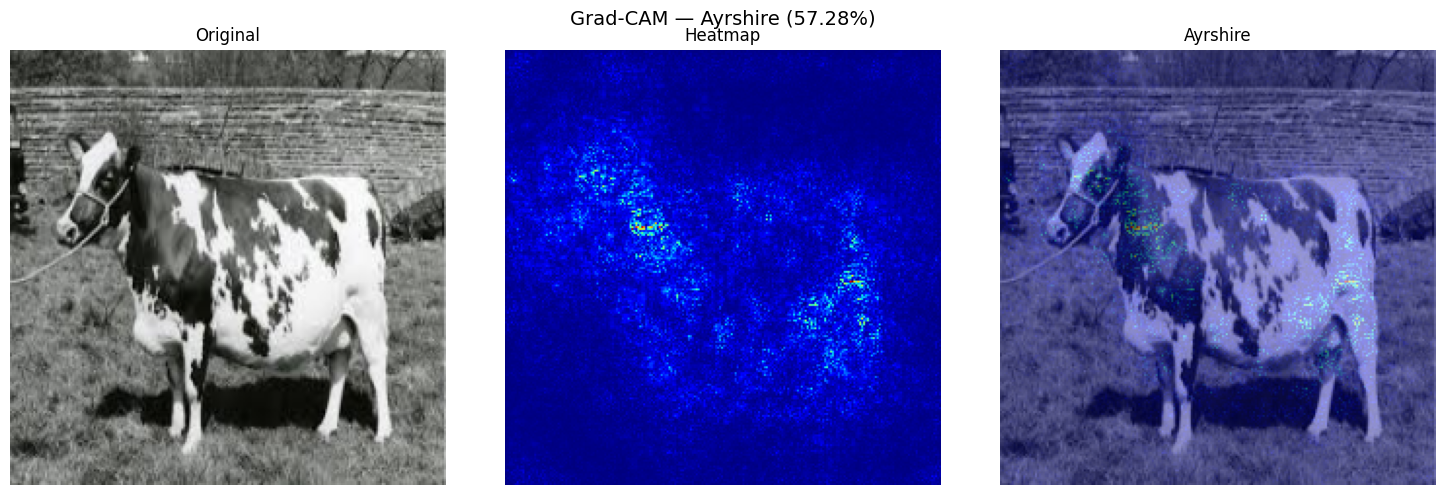

✅ Grad-CAM done!


In [10]:
# CELL 10 — Grad-CAM Test
import numpy as np, matplotlib.pyplot as plt
import cv2, tensorflow as tf, glob, json, os
from tensorflow.keras.preprocessing import image

def generate_gradcam(model, img_array, class_idx):
    img_t = tf.Variable(tf.cast(img_array, tf.float32))
    with tf.GradientTape() as tape:
        tape.watch(img_t)
        preds = model(img_t, training=False)
        loss  = preds[:, class_idx]
    grads   = tape.gradient(loss, img_t)
    grads   = tf.abs(grads)
    heatmap = tf.reduce_max(grads, axis=-1)[0]
    heatmap = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

breed_model = tf.keras.models.load_model('/content/breed_model.keras')
with open('/content/breed_classes.json') as f:
    bc = json.load(f)
idx_to_breed = {v:k for k,v in bc.items()}

test_imgs = [f for f in
             glob.glob('/content/data/breed/test/*/*.*')
             if f.lower().endswith(('.jpg','.jpeg','.png'))]

if test_imgs:
    test_img  = test_imgs[0]
    img_arr   = image.img_to_array(
        image.load_img(test_img, target_size=(224,224))) / 255.0
    img_input = np.expand_dims(img_arr, 0)
    pred      = breed_model.predict(img_input, verbose=0)
    class_idx = int(np.argmax(pred[0]))
    conf      = round(float(np.max(pred[0]))*100, 2)
    name      = idx_to_breed.get(class_idx, f'Class_{class_idx}')
    print(f'Breed: {name} ({conf}%)')

    heatmap = generate_gradcam(breed_model, img_input, class_idx)
    orig    = cv2.imread(test_img)
    orig    = cv2.resize(orig, (224,224))
    h_res   = cv2.resize(heatmap, (224,224))
    colored = cv2.applyColorMap(np.uint8(255*h_res), cv2.COLORMAP_JET)
    overlay = cv2.addWeighted(orig, 0.6, colored, 0.4, 0)

    fig, axes = plt.subplots(1,3,figsize=(15,5))
    fig.suptitle(f'Grad-CAM — {name} ({conf}%)', fontsize=14)
    axes[0].imshow(cv2.cvtColor(cv2.resize(cv2.imread(test_img),(224,224)),
                                cv2.COLOR_BGR2RGB))
    axes[0].set_title('Original'); axes[0].axis('off')
    axes[1].imshow(heatmap, cmap='jet')
    axes[1].set_title('Heatmap'); axes[1].axis('off')
    axes[2].imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
    axes[2].set_title(name); axes[2].axis('off')
    plt.tight_layout()
    plt.savefig('/content/gradcam_test.png', dpi=150)
    plt.show()
    print('✅ Grad-CAM done!')
else:
    print('No test images found')

In [11]:
# CELL 11 — Download ALL files
from google.colab import files
import os

download_list = [
    '/content/breed_model.keras',
    '/content/health_model.keras',
    '/content/bcs_model.keras',
    '/content/breed_classes.json',
    '/content/health_classes.json',
    '/content/bcs_classes.json',
    '/content/gradcam_test.png',
]

for f in download_list:
    if os.path.exists(f):
        print(f'⬇️  Downloading {os.path.basename(f)}...')
        files.download(f)
    else:
        print(f'⚠️  Not found: {os.path.basename(f)}')

print('\n✅ All downloads done!')
print('Place .keras files → cattleai_final/models/')
print('Place .json files  → cattleai_final/')
print('Run: python app.py')

⬇️  Downloading breed_model.keras...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Downloading health_model.keras...


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

⬇️  Downloading gradcam_test.png...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ All downloads done!
Place .keras files → cattleai_final/models/
Place .json files  → cattleai_final/
Run: python app.py
